In [16]:
# ============================================
# CELL 1 — CLONE REPO
# ============================================

%cd /kaggle/working
!git clone https://github.com/PhuongThao-2005/LViT.git
!git checkout BTRXD-small

%cd /kaggle/working/LViT


/kaggle/working
fatal: destination path 'LViT' already exists and is not an empty directory.
fatal: not a git repository (or any parent up to mount point /kaggle)
Stopping at filesystem boundary (GIT_DISCOVERY_ACROSS_FILESYSTEM not set).
/kaggle/working/LViT


In [17]:
# ============================================
# CELL 2 — COPY DATASET
# ============================================

!cp -r /kaggle/input/datasets/phuongthao205/btrxd-small/BTRXD_tumor_l100 /kaggle/working/LViT/datasets/

In [18]:
# ============================================
# CELL 3 — MOVE TO REPO
# ============================================

%cd /kaggle/working/LViT

/kaggle/working/LViT


In [19]:
# ============================================
# CELL 4 — CHECK DATASET STRUCTURE
# ============================================

import os

print(os.listdir("./datasets"))

print(os.listdir("./datasets/BTRXD_tumor_l100"))

print(os.listdir("./datasets/BTRXD_tumor_l100/Train_Folder"))

print(os.listdir("./datasets/BTRXD_tumor_l100/Train_Folder/img")[:5])

print(os.listdir("./datasets/BTRXD_tumor_l100/Train_Folder/labelcol")[:5])

['MoNuSeg', 'BTRXD_tumor_l100']
['label_plan_25.csv', 'split_info.csv', 'Train_Folder', 'Test_Folder', 'label_plan_100.csv', 'label_plan_50.csv', 'Val_Folder']
['Train_text.xlsx', 'labelcol', 'img']
['IMG000110.png', 'IMG000979.png', 'IMG001063.png', 'IMG000130.png', 'IMG000072.png']
['IMG000110.png', 'IMG000979.png', 'IMG001063.png', 'IMG000130.png', 'IMG000072.png']


IMG000110.png
(224, 224)
L


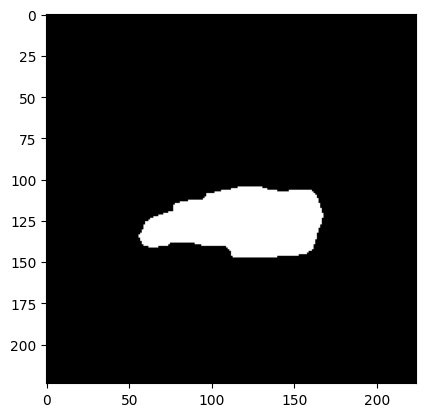

In [20]:
# ============================================
# CELL 5 — VISUALIZE MASK
# ============================================

from PIL import Image
import matplotlib.pyplot as plt

mask_dir = "./datasets/BTRXD_tumor_l100/Train_Folder/labelcol"

sample = os.listdir(mask_dir)[0]

print(sample)

mask = Image.open(os.path.join(mask_dir, sample))

print(mask.size)
print(mask.mode)

plt.imshow(mask, cmap="gray")
plt.show()

In [21]:
# ============================================
# CELL 6 — INSTALL PACKAGE
# ============================================

!pip install openpyxl
!pip install tensorboardX
!pip install thop

In [29]:
# ============================================
# CELL 9 — TEST DATASET
# ============================================

from PIL import Image
import numpy as np

img_dir = "./datasets/BTRXD_tumor_l100/Train_Folder/img"

mask_dir = "./datasets/BTRXD_tumor_l100/Train_Folder/labelcol"

img_name = sorted(os.listdir(img_dir))[0]

mask_name = sorted(os.listdir(mask_dir))[0]

print("image:", img_name)
print("mask :", mask_name)

img = Image.open(os.path.join(img_dir, img_name)).convert("RGB")

mask = Image.open(os.path.join(mask_dir, mask_name)).convert("L")

img = np.array(img)

mask = np.array(mask)

print("image shape:", img.shape)

print("mask shape:", mask.shape)

print("mask unique:", np.unique(mask))

image: IMG000001.png
mask : IMG000001.png
image shape: (224, 224, 3)
mask shape: (224, 224)
mask unique: [  0 255]


In [ ]:
# ============================================
# CELL 10 — START TRAINING
# ============================================

!python train_model.py

transformer head num: 4
transformer layers num: 4
transformer expand ratio: 4
Using device: cuda
Training device (from model): cuda:0
Loaded 0 unlabeled train samples from plan CSV.
LViT
TensorBoard log dir: /kaggle/working/BTRXD_tumor_l100/LViT/DEBUG_05.11_07h32/tensorboard_logs/

========= Epoch [1/201] =========
DEBUG_05.11_07h32
Training with batch size : 1
   [Train] Epoch: [1][50/1307]  Loss:0.848 (Avg 0.7240) IoU:0.017 (Avg 0.0597) Dice:0.0340 (Avg 0.1025) LR 3.00e-04   (AvgTime 0.1)   
   [Train] Epoch: [1][100/1307]  Loss:0.730 (Avg 0.7138) IoU:0.020 (Avg 0.0549) Dice:0.0401 (Avg 0.0968) LR 3.00e-04   (AvgTime 0.1)   
   [Train] Epoch: [1][150/1307]  Loss:0.537 (Avg 0.7111) IoU:0.253 (Avg 0.0521) Dice:0.4040 (Avg 0.0924) LR 3.00e-04   (AvgTime 0.1)   
   [Train] Epoch: [1][200/1307]  Loss:0.740 (Avg 0.7016) IoU:0.005 (Avg 0.0582) Dice:0.0094 (Avg 0.1008) LR 3.00e-04   (AvgTime 0.1)   
   [Train] Epoch: [1][250/1307]  Loss:0.672 (Avg 0.6964) IoU:0.033 (Avg 0.0591) Dice:0.0633 (

In [ ]:
!python train_model.py

In [31]:
# ============================================
# CELL 11 — CHECK OUTPUT
# ============================================

!ls /kaggle/working/

!find /kaggle/working -name "*.pth.tar"

BTRXD_tumor_l100  LViT
